# Exploratory Data Analysis - Capstone Project

## Imports and Data Load

In [975]:
#For Data Manipulation
import pandas as pd
import numpy as np

#For Visualizations
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"
import seaborn as sns
import plotly.express as px
import sys 

#For Displays
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option("display.width", None)

#Plot Styling
sns.set_style('whitegrid')

import nbformat

print(nbformat.__version__)

5.10.4


In [976]:
# Load cleaned roster dataset
clean_rosters_df = pd.read_csv("../data/processed/rosters_clean.csv")

clean_rosters_df.head()

,jersey_number,player_name,position,class_year,high_school,previous_school,school_name,division,conference_code,primary_conference,source_url,collected_at,height_inches,hometown_city,hometown_state,hometown_country,season
0,1.0,Becca Siedenburg,S,SR,Kettle Moraine HS,Gardner-Webb,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,68.0,Wales,WI,USA,2025
1,2.0,Avery Thaler,MB,SO,Fairfield HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,70.0,Fairfield,TX,USA,2025
2,4.0,Rachel Koss,S,JR,Freedom HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,71.0,Freedom,WI,USA,2025
3,5.0,Courtney Church,OH,R-FR,Veritas Academy,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,72.0,Driftwood,TX,USA,2025
4,7.0,Hannah Gonzalez,MB,JR,Lovejoy HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,74.0,Lucas,TX,USA,2025


## Data Inspection

In [977]:
# Dataset Dimensions
# This will tell us how many rows and columns are in the dataframe. This is recorded as
# (rows, columns).
clean_rosters_df.shape

(2123, 17)

In [978]:
# Column Names and Data Types
# This will tell us all of the column names in the dataframe, as well as what type of data
# is stored in each column.
clean_rosters_df.info()
# You can see there is mostly string types in this set, meaning free text.
# There is also a few integer types or float, which are numeric values.
# As this is mostly string data, our cleaning process was VERY important to get our data
# to be usable and correct for analysis.

<class 'pandas.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   jersey_number       2103 non-null   float64
 1   player_name         2123 non-null   str    
 2   position            2091 non-null   str    
 3   class_year          1966 non-null   str    
 4   high_school         1609 non-null   str    
 5   previous_school     207 non-null    str    
 6   school_name         2123 non-null   str    
 7   division            2123 non-null   str    
 8   conference_code     2123 non-null   str    
 9   primary_conference  2123 non-null   str    
 10  source_url          2123 non-null   str    
 11  collected_at        2123 non-null   str    
 12  height_inches       1820 non-null   float64
 13  hometown_city       2123 non-null   str    
 14  hometown_state      1891 non-null   str    
 15  hometown_country    2123 non-null   str    
 16  season           

In [979]:
# Preview of the Data
clean_rosters_df.head(10)
# This shows us the first 10 rows of the dataset. As our data is categorized by school (as
# it was how it was pulled), these players will likely be from the same university.

,jersey_number,player_name,position,class_year,high_school,previous_school,school_name,division,conference_code,primary_conference,source_url,collected_at,height_inches,hometown_city,hometown_state,hometown_country,season
0,1.0,Becca Siedenburg,S,SR,Kettle Moraine HS,Gardner-Webb,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,68.0,Wales,WI,USA,2025
1,2.0,Avery Thaler,MB,SO,Fairfield HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,70.0,Fairfield,TX,USA,2025
2,4.0,Rachel Koss,S,JR,Freedom HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,71.0,Freedom,WI,USA,2025
3,5.0,Courtney Church,OH,R-FR,Veritas Academy,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,72.0,Driftwood,TX,USA,2025
4,7.0,Hannah Gonzalez,MB,JR,Lovejoy HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,74.0,Lucas,TX,USA,2025
5,8.0,Annaleise Sevier,OH,SO,Aubrey HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,70.0,Aubrey,TX,USA,2025
6,9.0,Ashli Edmiston,OH,SR,Wilsonville HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,68.0,Wilsonville,OR,USA,2025
7,10.0,Aubrey Beaver,OH,JR,Temecula Valley HS,Cal State Fullerton,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,72.0,Murrieta,CA,USA,2025
8,11.0,Izabelle Larson,OH,JR,Santa Teresa HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,71.0,San Jose,CA,USA,2025
9,12.0,Abby Christian,L/DS,JR,Liberty North HS,NaN,Abilene Christian University,DI,WAC,Western Athletic Conference,https://acusports.com/sports/womens-volleyball...,2026-07-20T00:46:56.672717+00:00,69.0,Kansas City,MO,USA,2025


In [980]:
# Checking for Duplicates
# As there could be multiple people in the dataset with the same name (Emily Smith, for example), 
# we will check for duplicates based on the combination of first name, last name, and school. 
# This will help us identify if there are any duplicate entries in the dataset.
clean_rosters_df.duplicated(subset=["player_name", "school_name"]).sum()
# With the result of 0, we can confidently say there are no duplicate athletes in the df.

np.int64(0)

In [981]:
# Calculating Missing Values by Column
# In the informational code, we learned there are some missing data in columns. This could be 
# due to data not being available, like if someone was an international student or if someone
# did not transfer, so there's not a previous school available.
# This code calculates the precentage of missing values from each column.
# Calculate missing values by column
missing_values = pd.DataFrame({
    "missing_count": clean_rosters_df.isnull().sum(),
    "missing_percent": (clean_rosters_df.isnull().sum() / len(clean_rosters_df) * 100).round(2)
})

missing_values.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
previous_school,1916,90.25
high_school,514,24.21
height_inches,303,14.27
hometown_state,232,10.93
class_year,157,7.40
position,32,1.51
jersey_number,20,0.94
player_name,0,0.00
school_name,0,0.00
conference_code,0,0.00


In [982]:
# Review unique categorical values
for column in ["position", "class_year", "division", 
               "conference_code", "hometown_country", "season"]:
    print(f"\n{column.upper()}")
    print(clean_rosters_df[column].value_counts(dropna=False))


POSITION
position
OH      652
MB      548
S       382
L/DS    345
OPP     164
NaN      32
Name: count, dtype: int64

CLASS_YEAR
class_year
FR             567
SO             410
JR             389
SR             334
NaN            157
GR              76
R-FR            56
R-SO            53
R-JR            43
R-SR            17
FY.              9
FY               4
RF.              2
5TH              2
R-JUNIOR         2
RFR.             1
R-SOPHOMORE      1
Name: count, dtype: int64

DIVISION
division
DI    2123
Name: count, dtype: int64

CONFERENCE_CODE
conference_code
MVC              141
MAAC             128
Southland        123
SWAC             111
Summit           102
WAC               96
ACC               95
CAA               92
Big Sky           89
Big East          85
Horizon           78
ASUN              74
WCC               74
CUSA              73
MEAC              71
Mountain West     61
SBC               57
A10               54
SEC               53
Big West          49
PL

## Feature Engineering

In [983]:
# Copying the original dataframe so we can feature engineer and have something 
# to fall back on!
crfedf = clean_rosters_df.copy()

In [984]:
# Standardizing Records
# We're changing FY and FY. to be FR, as first years are also freshmen.
crfedf["class_year"] = crfedf["class_year"].replace({
    "FY": "FR",
    "FY.": "FR",
    "RF.": "R-FR",
    "RFR.": "R-FR",
    "5TH": "R-SR",
    "R-JUNIOR": "R-JR",
    "R-SOPHOMORE": "R-SO"
})

# Remove features not relevant to the analysis
# Jersey numbers and the high school name are not relevant to success.
# We will remove these columns as we have a city and state available for the player.
crfedf = crfedf.drop(columns=[
    "jersey_number",
    "high_school"
])

# We are verifying the shape change and acquiring information on the new df.
crfedf.shape
crfedf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player_name         2123 non-null   str    
 1   position            2091 non-null   str    
 2   class_year          1966 non-null   str    
 3   previous_school     207 non-null    str    
 4   school_name         2123 non-null   str    
 5   division            2123 non-null   str    
 6   conference_code     2123 non-null   str    
 7   primary_conference  2123 non-null   str    
 8   source_url          2123 non-null   str    
 9   collected_at        2123 non-null   str    
 10  height_inches       1820 non-null   float64
 11  hometown_city       2123 non-null   str    
 12  hometown_state      1891 non-null   str    
 13  hometown_country    2123 non-null   str    
 14  season              2123 non-null   int64  
dtypes: float64(1), int64(1), str(13)
memory usage: 248.9 KB


## Feature Validation

In [985]:
# Review categorical variables after feature engineering
categorical_columns = [
    "position",
    "class_year",
    "division",
    "conference_code",
    "hometown_state",
    "hometown_country"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(crfedf[column].value_counts(dropna=False))


POSITION
position
OH      652
MB      548
S       382
L/DS    345
OPP     164
NaN      32
Name: count, dtype: int64

CLASS_YEAR
class_year
FR      580
SO      410
JR      389
SR      334
NaN     157
GR       76
R-FR     59
R-SO     54
R-JR     45
R-SR     19
Name: count, dtype: int64

DIVISION
division
DI    2123
Name: count, dtype: int64

CONFERENCE_CODE
conference_code
MVC              141
MAAC             128
Southland        123
SWAC             111
Summit           102
WAC               96
ACC               95
CAA               92
Big Sky           89
Big East          85
Horizon           78
ASUN              74
WCC               74
CUSA              73
MEAC              71
Mountain West     61
SBC               57
A10               54
SEC               53
Big West          49
PL                48
B12               47
Mid American      46
Ohio Valley       46
American          37
Big South         36
America East      35
IVY               33
B10               33
Southern        

In [986]:
# Review countries represented in the dataset
crfedf["hometown_country"].value_counts(dropna=False)

hometown_country
USA                   1854
Turkey                  34
Brazil                  32
Italy                   29
Poland                  27
PR                      20
CAN                     17
Serbia                  13
Argentina                8
Canada                   8
Sweden                   5
Hungary                  5
Greece                   5
Germany                  5
Netherlands              5
France                   5
Bulgaria                 4
Peru                     4
Slovenia                 3
Czech Republic           3
Cyprus                   3
New Zealand              3
Costa Rica               2
Colombia                 2
Mexico                   2
Spain                    2
Romania                  2
Egypt                    2
Slovakia                 2
Brasil                   2
Japan                    2
Croatia                  2
Finland                  2
Taiwan                   1
Estonia                  1
Ukraine                  1
Czechia    

In [987]:
# Review U.S. state/province values
sorted(crfedf["hometown_state"].dropna().unique())

['AB',
 'AL',
 'AR',
 'AZ',
 'Alberta',
 'BC',
 'Bursa',
 'CA',
 'CO',
 'CT',
 'DC',
 'DE',
 'FL',
 'GA',
 'HI',
 'IA',
 'ID',
 'IL',
 'IN',
 'Istanbul',
 'Izmir',
 'KS',
 'KY',
 'LA',
 'MA',
 'MB',
 'MD',
 'ME',
 'MI',
 'MN',
 'MO',
 'MS',
 'MT',
 'Manitoba',
 'Mato Grosso',
 'Mugla',
 'NC',
 'ND',
 'NE',
 'NH',
 'NJ',
 'NM',
 'NV',
 'NY',
 'OH',
 'OK',
 'ON',
 'OR',
 'PA',
 'Paraná',
 'QC',
 'Rio de Janeiro',
 'SC',
 'SD',
 'San Juan',
 'San Juan Province',
 'Santa Catarina',
 'TN',
 'TX',
 'UT',
 'VA',
 'WA',
 'WI',
 'WV',
 'WY',
 'Wielkopolska']

In [988]:
# Reviewing Cleaned Work
# Review cleaned position categories
crfedf["position"].value_counts(dropna=False)

position
OH      652
MB      548
S       382
L/DS    345
OPP     164
NaN      32
Name: count, dtype: int64

In [989]:
# Review cleaned class-year categories
crfedf["class_year"].value_counts(dropna=False)

class_year
FR      580
SO      410
JR      389
SR      334
NaN     157
GR       76
R-FR     59
R-SO     54
R-JR     45
R-SR     19
Name: count, dtype: int64

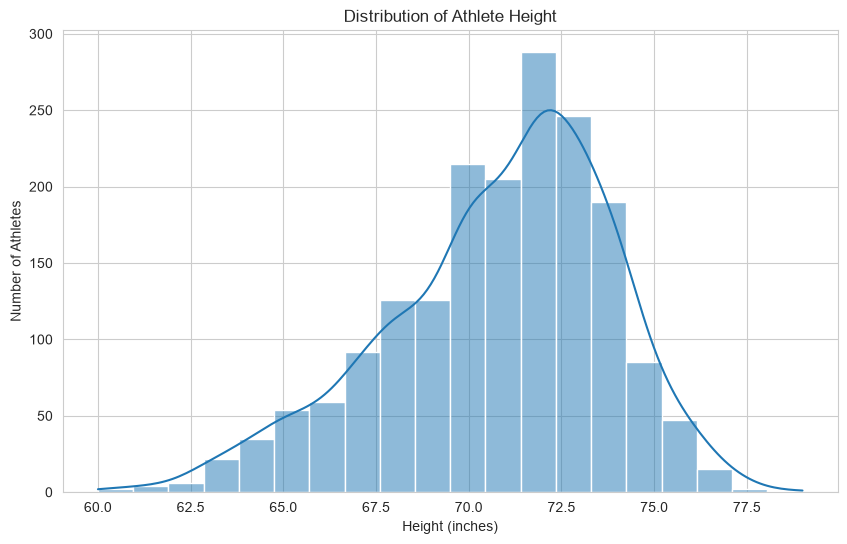

,count,mean,median,std,min,max
position,,,,,,
L/DS,292,66.12,66.0,2.16,60.0,72.0
MB,474,73.16,73.0,1.75,67.0,78.0
OH,564,71.45,71.0,1.89,63.0,77.0
OPP,145,72.57,72.0,1.95,68.0,77.0
S,334,69.70,70.0,2.17,64.0,77.0


In [990]:
# Exploring Height
# Summary statistics for athlete height
crfedf["height_inches"].describe()

# Median athlete height
crfedf["height_inches"].median()

# Distribution of athlete height
plt.figure(figsize=(10, 6))

sns.histplot(
    data=crfedf,
    x="height_inches",
    bins=20,
    kde=True
)

plt.title("Distribution of Athlete Height")
plt.xlabel("Height (inches)")
plt.ylabel("Number of Athletes")
plt.show()

# Height summary by position
height_by_position = (
    crfedf.groupby("position")["height_inches"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

height_by_position

In [991]:
# Identify heights that were missing in the original dataset
crfedf["height_imputed"] = crfedf["height_inches"].isna()

crfedf["height_imputed"].value_counts()

height_imputed
False    1820
True      303
Name: count, dtype: int64

In [992]:
# Imputing height average per position who does not have heights represented
# Calculate mean height for each position
position_height_mean = crfedf.groupby("position")["height_inches"].transform("mean")

# Fill missing heights using the athlete's position mean
crfedf["height_inches"] = crfedf["height_inches"].fillna(position_height_mean)

In [993]:
# Fill any remaining missing heights with overall mean
crfedf["height_inches"] = crfedf["height_inches"].fillna(
    crfedf["height_inches"].mean()
)

In [994]:
# Identify heights that were missing in the original dataset
crfedf["height_imputed"] = crfedf["height_inches"].isna()

crfedf["height_imputed"].value_counts()

height_imputed
False    2123
Name: count, dtype: int64

## Exploratory Data Analysis

### Representation of Players and Schools

In [995]:
# Basic dataset summary
print(f"Total athletes: {len(crfedf):,}")
print(f"Unique schools: {crfedf['school_name'].nunique()}")
print(f"Divisions represented: {crfedf['division'].nunique()}")
print(f"Conferences represented: {crfedf['primary_conference'].nunique()}")
print(f"Countries represented: {crfedf['hometown_country'].nunique()}")

Total athletes: 2,123
Unique schools: 157
Divisions represented: 1
Conferences represented: 31
Countries represented: 42


In [996]:
# Counting Number of Schools Represented:
crfedf.groupby("division")["school_name"].nunique()

division
DI    157
Name: school_name, dtype: int64

### Height Distribution

In [997]:
# Descriptive statistics for athlete height
crfedf["height_inches"].describe().round(2)

count    2123.00
mean       70.80
std         2.98
min        60.00
25%        69.00
50%        71.00
75%        73.00
max        79.00
Name: height_inches, dtype: float64

In [998]:
# Key height statistics
mean_height = crfedf["height_inches"].mean()
median_height = crfedf["height_inches"].median()
std_height = crfedf["height_inches"].std()

print(f"Mean height: {mean_height:.2f} inches")
print(f"Median height: {median_height:.2f} inches")
print(f"Standard deviation: {std_height:.2f} inches")
print(f"Minimum height: {crfedf['height_inches'].min():.0f} inches")
print(f"Maximum height: {crfedf['height_inches'].max():.0f} inches")

Mean height: 70.80 inches
Median height: 71.00 inches
Standard deviation: 2.98 inches
Minimum height: 60 inches
Maximum height: 79 inches


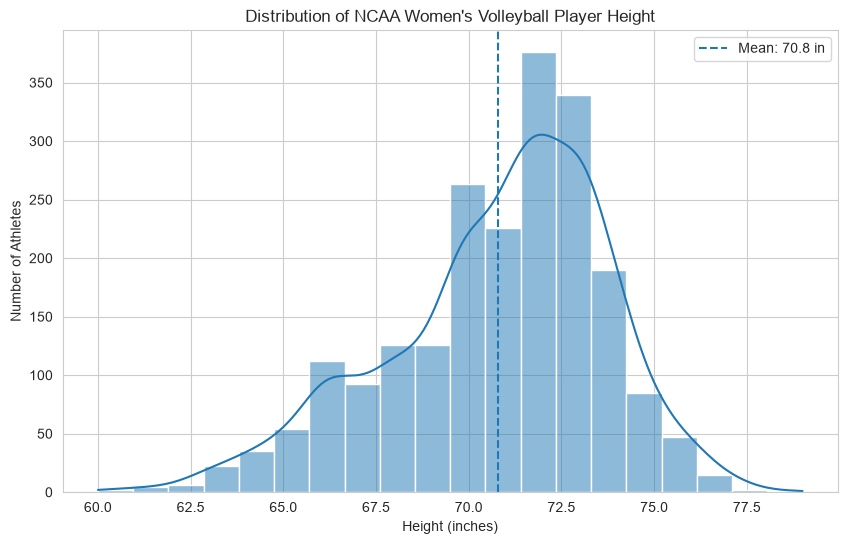

In [999]:
# Distribution of athlete height
plt.figure(figsize=(10, 6))

sns.histplot(
    data=crfedf,
    x="height_inches",
    bins=20,
    kde=True
)

plt.axvline(
    crfedf["height_inches"].mean(),
    linestyle="--",
    label=f"Mean: {crfedf['height_inches'].mean():.1f} in"
)

plt.title("Distribution of NCAA Women's Volleyball Player Height")
plt.xlabel("Height (inches)")
plt.ylabel("Number of Athletes")
plt.legend()

plt.show()

In [1000]:
# Average height by position
height_by_position = (
    crfedf.groupby("position")["height_inches"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .sort_values("mean", ascending=False)
)

height_by_position

,count,mean,median,std
position,,,,
MB,548,73.16,73.16,1.62
OPP,164,72.57,72.57,1.83
OH,652,71.45,71.45,1.76
S,382,69.70,69.70,2.03
L/DS,345,66.12,66.12,1.98


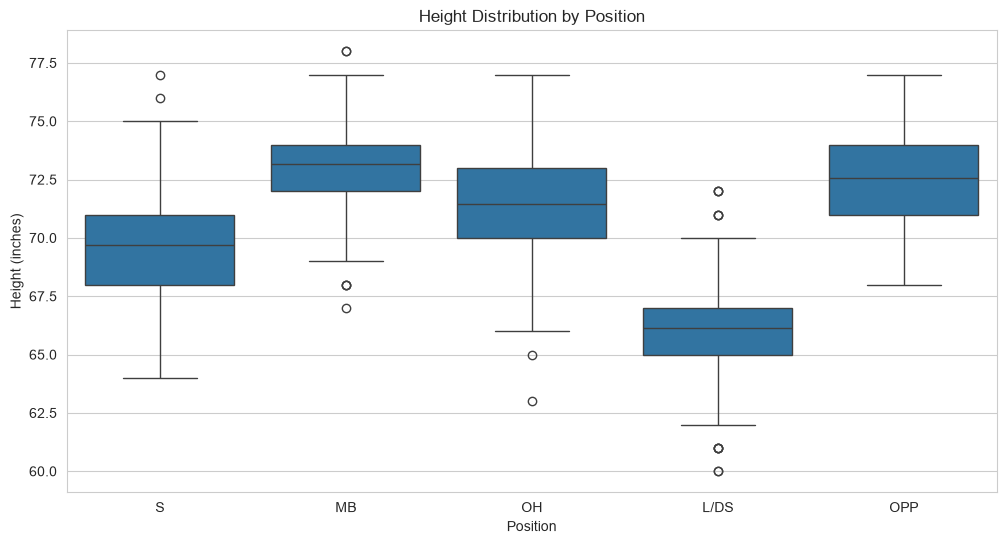

In [1001]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=crfedf,
    x="position",
    y="height_inches"
)

plt.title("Height Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Height (inches)")

plt.show()

### Position Work

In [1002]:
# Count athletes by position
position_counts = crfedf["position"].value_counts()

position_counts

position
OH      652
MB      548
S       382
L/DS    345
OPP     164
Name: count, dtype: int64

In [1003]:
# Calculate position counts and percentages
position_summary = (
    crfedf["position"]
    .value_counts()
    .rename_axis("position")
    .reset_index(name="count")
)

position_summary["percent"] = (
    position_summary["count"] / len(crfedf) * 100
).round(2)

position_summary

,position,count,percent
0,OH,652,30.71
1,MB,548,25.81
2,S,382,17.99
3,L/DS,345,16.25
4,OPP,164,7.72


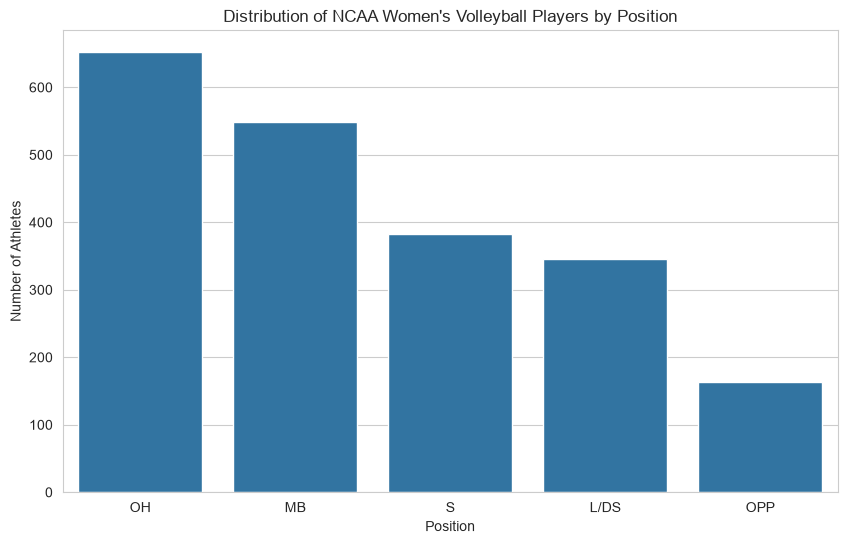

In [1004]:
# Visualize player distribution by position
plt.figure(figsize=(10, 6))

sns.countplot(
    data=crfedf,
    x="position",
    order=crfedf["position"].value_counts().index
)

plt.title("Distribution of NCAA Women's Volleyball Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Athletes")

plt.show()

In [1005]:
# Create school-by-position count table
school_position_counts = pd.crosstab(
    crfedf["school_name"],
    crfedf["position"]
)

# Average number of players at each position per school
school_position_counts.mean().round(2).sort_values(ascending=False)

position
OH      4.18
MB      3.51
S       2.45
L/DS    2.21
OPP     1.05
dtype: float64

### Class Year Representation

In [1006]:
# Count athletes by class year
class_counts = crfedf["class_year"].value_counts()

class_counts

class_year
FR      580
SO      410
JR      389
SR      334
GR       76
R-FR     59
R-SO     54
R-JR     45
R-SR     19
Name: count, dtype: int64

In [1007]:
# Calculate class-year counts and percentages
class_summary = (
    crfedf["class_year"]
    .value_counts()
    .rename_axis("class_year")
    .reset_index(name="count")
)

class_summary["percent"] = (
    class_summary["count"] / crfedf["class_year"].notna().sum() * 100
).round(2)

class_summary

,class_year,count,percent
0,FR,580,29.50
1,SO,410,20.85
2,JR,389,19.79
3,SR,334,16.99
4,GR,76,3.87
5,R-FR,59,3.00
6,R-SO,54,2.75
7,R-JR,45,2.29
8,R-SR,19,0.97


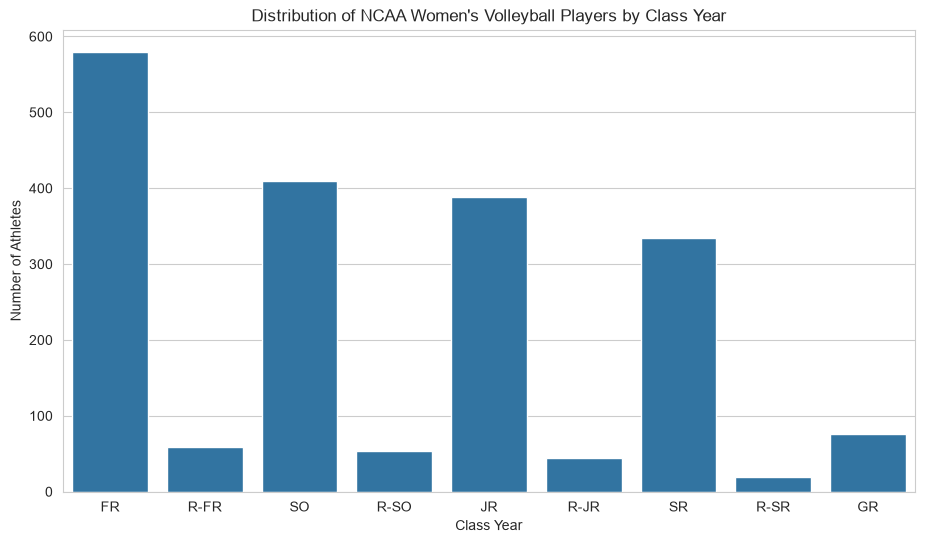

In [1008]:
# Define logical class-year order
class_order = [
    "FR", "R-FR",
    "SO", "R-SO",
    "JR", "R-JR",
    "SR", "R-SR",
    "GR"
]

plt.figure(figsize=(11, 6))

sns.countplot(
    data=crfedf,
    x="class_year",
    order=[
        year for year in class_order
        if year in crfedf["class_year"].dropna().unique()
    ]
)

plt.title("Distribution of NCAA Women's Volleyball Players by Class Year")
plt.xlabel("Class Year")
plt.ylabel("Number of Athletes")

plt.show()

### Country Wide Representation

In [1009]:
# Count athletes by country
country_counts = crfedf["hometown_country"].value_counts()

country_counts

hometown_country
USA                   1854
Turkey                  34
Brazil                  32
Italy                   29
Poland                  27
PR                      20
CAN                     17
Serbia                  13
Argentina                8
Canada                   8
Sweden                   5
Hungary                  5
Greece                   5
Germany                  5
Netherlands              5
France                   5
Bulgaria                 4
Peru                     4
Slovenia                 3
Czech Republic           3
Cyprus                   3
New Zealand              3
Costa Rica               2
Colombia                 2
Mexico                   2
Spain                    2
Romania                  2
Egypt                    2
Slovakia                 2
Brasil                   2
Japan                    2
Croatia                  2
Finland                  2
Taiwan                   1
Estonia                  1
Ukraine                  1
Czechia    

In [1010]:
print(
    f"Countries represented: "
    f"{crfedf['hometown_country'].nunique()}"
)

Countries represented: 42


In [1011]:
country_summary = (
    crfedf["hometown_country"]
    .value_counts()
    .rename_axis("country")
    .reset_index(name="count")
)

country_summary["percent"] = (
    country_summary["count"] / len(crfedf) * 100
).round(2)

country_summary

,country,count,percent
0,USA,1854,87.33
1,Turkey,34,1.60
2,Brazil,32,1.51
3,Italy,29,1.37
4,Poland,27,1.27
5,PR,20,0.94
6,CAN,17,0.80
7,Serbia,13,0.61
8,Argentina,8,0.38
9,Canada,8,0.38


In [1012]:
print(
    f"Countries represented: "
    f"{crfedf['hometown_country'].nunique()}"
)

Countries represented: 42


In [1013]:
international_players = crfedf[
    crfedf["hometown_country"] != "USA"
]

international_players["hometown_country"].value_counts()

hometown_country
Turkey                34
Brazil                32
Italy                 29
Poland                27
PR                    20
CAN                   17
Serbia                13
Argentina              8
Canada                 8
Sweden                 5
Hungary                5
Greece                 5
Germany                5
Netherlands            5
France                 5
Bulgaria               4
Peru                   4
Slovenia               3
Czech Republic         3
Cyprus                 3
New Zealand            3
Costa Rica             2
Colombia               2
Mexico                 2
Spain                  2
Romania                2
Egypt                  2
Slovakia               2
Brasil                 2
Japan                  2
Croatia                2
Finland                2
Taiwan                 1
Estonia                1
Ukraine                1
Czechia                1
Latvia                 1
Russia                 1
China                  1
Belarus 

In [1014]:
# U.S. athletes only
us_players = crfedf[
    crfedf["hometown_country"] == "USA"
]

state_counts = us_players["hometown_state"].value_counts()

state_counts

hometown_state
TX    326
CA    166
IL    112
FL     98
IN     73
OH     67
GA     62
AZ     61
NC     60
WI     53
MN     53
UT     47
MO     41
MI     40
VA     36
CO     36
NY     35
TN     33
IA     33
KY     32
PA     32
WA     32
MD     30
KS     30
LA     29
HI     24
NE     22
OR     20
NV     19
AR     19
NJ     18
AL     16
SC     14
ID     13
MA     11
SD     11
CT      9
MT      9
MS      8
OK      6
WV      4
NM      4
WY      3
NH      2
DE      2
DC      1
ME      1
ND      1
Name: count, dtype: int64

In [1015]:
state_summary = (
    us_players["hometown_state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="count")
)

state_summary["percent"] = (
    state_summary["count"] / len(us_players) * 100
).round(2)

state_summary.head(15)

,state,count,percent
0,TX,326,17.58
1,CA,166,8.95
2,IL,112,6.04
3,FL,98,5.29
4,IN,73,3.94
5,OH,67,3.61
6,GA,62,3.34
7,AZ,61,3.29
8,NC,60,3.24
9,WI,53,2.86


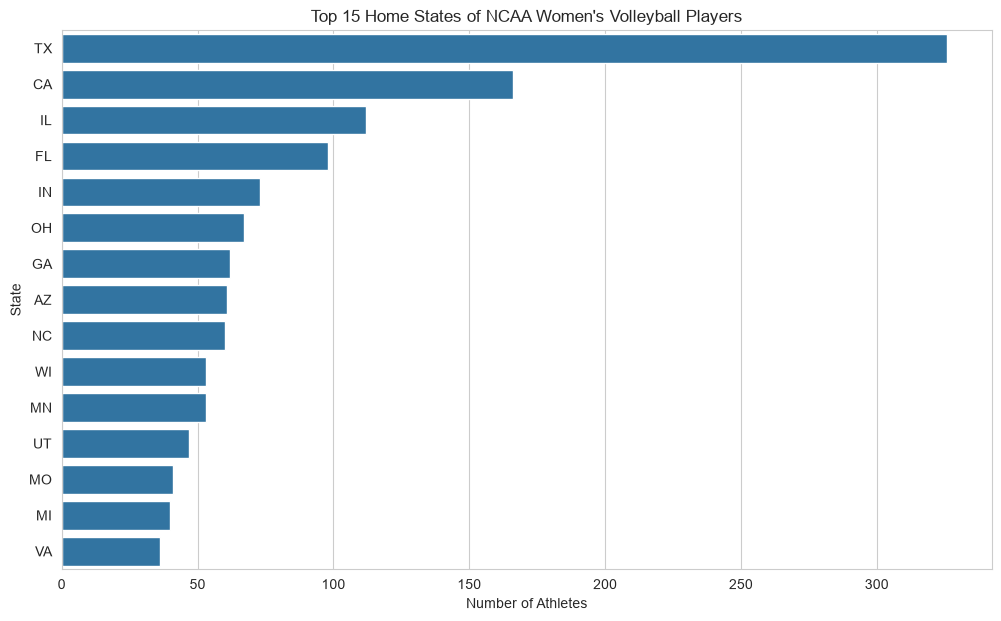

In [1016]:
top_states = state_summary.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_states,
    x="count",
    y="state"
)

plt.title("Top 15 Home States of NCAA Women's Volleyball Players")
plt.xlabel("Number of Athletes")
plt.ylabel("State")

plt.show()

### Summaries of Data

In [1017]:
# Top 10 countries represented
country_counts.head(10)


hometown_country
USA          1854
Turkey         34
Brazil         32
Italy          29
Poland         27
PR             20
CAN            17
Serbia         13
Argentina       8
Canada          8
Name: count, dtype: int64

In [1018]:
# Top 15 U.S. states represented
state_counts.head(10)

hometown_state
TX    326
CA    166
IL    112
FL     98
IN     73
OH     67
GA     62
AZ     61
NC     60
WI     53
Name: count, dtype: int64

In [1019]:
# Domestic vs. international athlete counts
domestic_count = (crfedf["hometown_country"] == "USA").sum()
international_count = (crfedf["hometown_country"] != "USA").sum()

print(f"Domestic athletes: {domestic_count:,}")
print(f"International athletes: {international_count:,}")
print(f"International share: {international_count / len(crfedf) * 100:.2f}%")

Domestic athletes: 1,854
International athletes: 269
International share: 12.67%


### City Concentration

In [1020]:
# Top U.S. hometown cities
city_summary = (
    us_players
    .groupby(["hometown_city", "hometown_state"])
    .size()
    .reset_index(name="player_count")
    .sort_values("player_count", ascending=False)
)

city_summary.head(20)

,hometown_city,hometown_state,player_count
445,Houston,TX,29
39,Atlanta,GA,17
239,Dallas,TX,16
48,Austin,TX,15
848,San Diego,CA,14
519,Las Vegas,NV,14
845,San Antonio,TX,13
457,Indianapolis,IN,11
900,Spring,TX,11
558,Louisville,KY,11


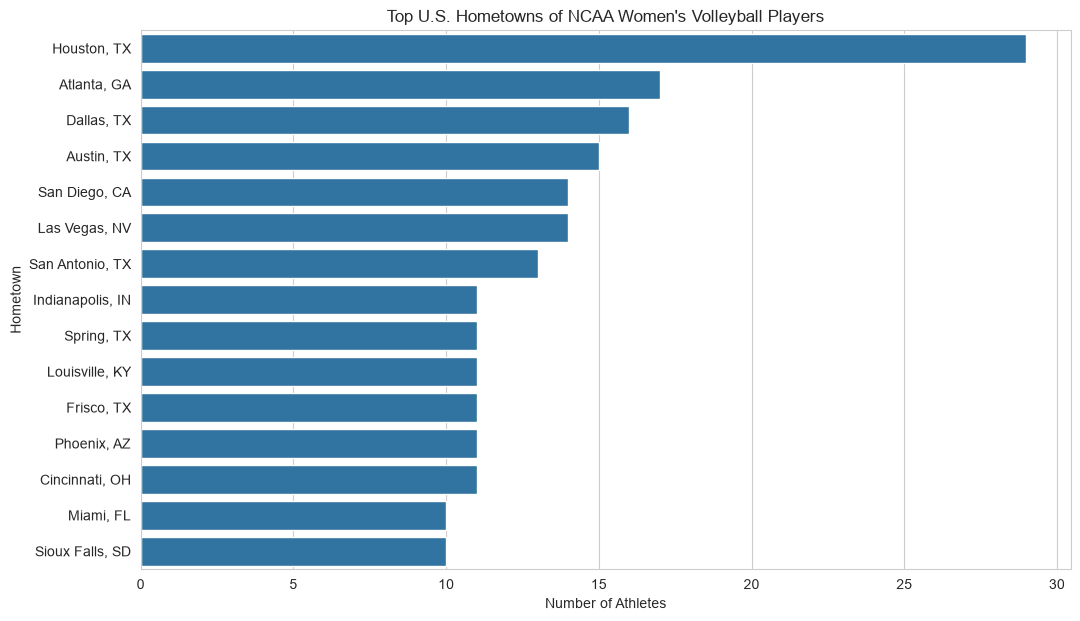

In [1021]:
top_cities = city_summary.head(15).copy()

top_cities["location"] = (
    top_cities["hometown_city"]
    + ", "
    + top_cities["hometown_state"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_cities,
    x="player_count",
    y="location"
)

plt.title("Top U.S. Hometowns of NCAA Women's Volleyball Players")
plt.xlabel("Number of Athletes")
plt.ylabel("Hometown")

plt.show()

### State Concentration by Top Hometown

In [1022]:
# Count players by city within each state
city_state_counts = (
    us_players
    .groupby(["hometown_state", "hometown_city"])
    .size()
    .reset_index(name="city_player_count")
)

# Total players from each state
state_totals = (
    us_players
    .groupby("hometown_state")
    .size()
    .reset_index(name="state_player_count")
)

# Identify the city with the most players in each state
top_city_by_state = (
    city_state_counts
    .sort_values(
        ["hometown_state", "city_player_count"],
        ascending=[True, False]
    )
    .drop_duplicates("hometown_state")
)

# Add state totals
state_concentration = top_city_by_state.merge(
    state_totals,
    on="hometown_state"
)

# Calculate percentage of state's players from top city
state_concentration["top_city_percent"] = (
    state_concentration["city_player_count"]
    / state_concentration["state_player_count"]
    * 100
).round(2)

state_concentration = state_concentration.sort_values(
    "top_city_percent",
    ascending=False
)

state_concentration.head(20)

,hometown_state,hometown_city,city_player_count,state_player_count,top_city_percent
6,DC,Washington,1,1,100.00
7,DE,Wilmington,2,2,100.00
27,ND,Fargo,1,1,100.00
20,ME,Wiscasset,1,1,100.00
39,SD,Sioux Falls,10,11,90.91
32,NV,Las Vegas,14,19,73.68
31,NM,Albuquerque,2,4,50.00
29,NH,Barrington,1,2,50.00
36,OR,Portland,8,20,40.00
16,KY,Louisville,11,32,34.38


In [1023]:
state_concentration_filtered = (
    state_concentration[
        state_concentration["state_player_count"] >= 10
    ]
    .sort_values("top_city_percent", ascending=False)
)

state_concentration_filtered

,hometown_state,hometown_city,city_player_count,state_player_count,top_city_percent
39,SD,Sioux Falls,10,11,90.91
32,NV,Las Vegas,14,19,73.68
36,OR,Portland,8,20,40.00
16,KY,Louisville,11,32,34.38
28,NE,Lincoln,7,22,31.82
9,GA,Atlanta,17,62,27.42
10,HI,Honolulu,6,24,25.00
4,CO,Parker,8,36,22.22
40,TN,Memphis,7,33,21.21
17,LA,Baton Rouge,6,29,20.69


In [1024]:
state_concentration_filtered.sort_values(
    "top_city_percent"
).head(10)

,hometown_state,hometown_city,city_player_count,state_player_count,top_city_percent
37,PA,Bridgeville,2,32,6.25
13,IL,Chicago,8,112,7.14
45,WI,Appleton,4,53,7.55
3,CA,San Diego,14,166,8.43
42,UT,Herriman,4,47,8.51
33,NY,Lancaster,3,35,8.57
41,TX,Houston,29,326,8.90
11,IA,Dike,3,33,9.09
18,MA,Boxford,1,11,9.09
22,MN,Lakeville,5,53,9.43


In [1025]:
# Count unique hometown cities represented in each state
state_city_diversity = (
    us_players
    .groupby("hometown_state")["hometown_city"]
    .nunique()
    .reset_index(name="unique_cities")
)

state_geography = state_concentration.merge(
    state_city_diversity,
    on="hometown_state"
)

state_geography[
    [
        "hometown_state",
        "state_player_count",
        "unique_cities",
        "hometown_city",
        "city_player_count",
        "top_city_percent"
    ]
].sort_values(
    "state_player_count",
    ascending=False
)

,hometown_state,state_player_count,unique_cities,hometown_city,city_player_count,top_city_percent
41,TX,326,116,Houston,29,8.90
44,CA,166,99,San Diego,14,8.43
46,IL,112,72,Chicago,8,7.14
37,FL,98,47,Miami,10,10.20
29,IN,73,44,Indianapolis,11,15.07
26,OH,67,44,Cincinnati,11,16.42
14,GA,62,29,Atlanta,17,27.42
24,AZ,61,18,Phoenix,11,18.03
34,NC,60,37,Charlotte,7,11.67
45,WI,53,40,Appleton,4,7.55


### Mapping

In [1026]:
state_map = (
    us_players
    .groupby("hometown_state")
    .size()
    .reset_index(name="player_count")
)

state_map.head()

,hometown_state,player_count
0,AL,16
1,AR,19
2,AZ,61
3,CA,166
4,CO,36


In [1027]:
fig = px.choropleth(
    state_map,
    locations="hometown_state",
    locationmode="USA-states",
    color="player_count",
    scope="usa",
    hover_name="hometown_state",
    hover_data={"player_count": True},
    labels={
        "player_count": "Number of Athletes",
        "hometown_state": "State"
    },
    title="Geographic Distribution of 2025 NCAA Women's Volleyball Players"
)

In [1028]:
fig.update_layout(
    title_x=0.5,
    geo=dict(
        lakecolor="white"
    )
)

fig.show()

In [1029]:
# Implementing this dataset as a CSV.

crfedf.to_csv(
    "../data/processed/crfedf.csv",
    index=False
)